# Laboratório de Redes Neurais — MNIST com Keras
**UFPR/DINF**

**Disciplina:** Aprendizagem de Máquina (CI-1171/INFO-7004)

**Objetivo:** Explorar experimentalmente o impacto de otimizadores e hiperparâmetros no treinamento de MLPs na base MNIST.

---

## Estrutura do Laboratório

| # | Experimento | O que você vai observar |
|---|---|---|
| 1 | **Baseline** | MLP simples como ponto de partida |
| 2 | **Otimizadores** | SGD × Adam × RMSProp × Adagrad |
| 3 | **Taxa de Aprendizado** | LR muito alto, ideal e muito baixo |
| 4 | **Arquitetura** | Profundidade × largura da rede |
| 5 | **Batch Size** | Impacto no ruído e generalização |
| 6 | **Funções de Ativação** | ReLU × Sigmoid × Tanh × ELU |

> Execute as células em ordem. Ao final de cada experimento, responda às perguntas. **Submeta um PDF com suas respostas.**

---
## Setup e Upload dos Dados

In [ ]:
# Execute esta célula se estiver no Google Colab
# !pip install tensorflow matplotlib seaborn pandas -q

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.datasets import mnist

# Reprodutibilidade
tf.random.set_seed(42)
np.random.seed(42)

print(f'TensorFlow: {tf.__version__}')
print(f'Keras: {keras.__version__}')
print(f'GPU disponível: {len(tf.config.list_physical_devices("GPU")) > 0}')

I0000 00:00:1777568612.130320 1289482 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777568612.132943 1289482 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777568612.167084 1289482 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0
Keras: 3.14.0
GPU disponível: False


I0000 00:00:1777568613.057704 1289482 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777568613.058169 1289482 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1777568613.226256 1289482 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
# ── Carregamento e pré-processamento ──────────────────────────────────────────
(X_train_raw, y_train), (X_test_raw, y_test) = mnist.load_data()

# Normalização [0, 255] → [0, 1] e flatten 28×28 → 784
X_train = X_train_raw.reshape(-1, 784).astype('float32') / 255.0
X_test  = X_test_raw.reshape(-1, 784).astype('float32') / 255.0

# Separar conjunto de validação
X_val, y_val     = X_train[50000:], y_train[50000:]
X_train, y_train = X_train[:50000], y_train[:50000]

print(f'Treino:     {X_train.shape}  |  {y_train.shape}')
print(f'Validação:  {X_val.shape}    |  {y_val.shape}')
print(f'Teste:      {X_test.shape}   |  {y_test.shape}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Treino:     (50000, 784)  |  (50000,)
Validação:  (10000, 784)    |  (10000,)
Teste:      (10000, 784)   |  (10000,)


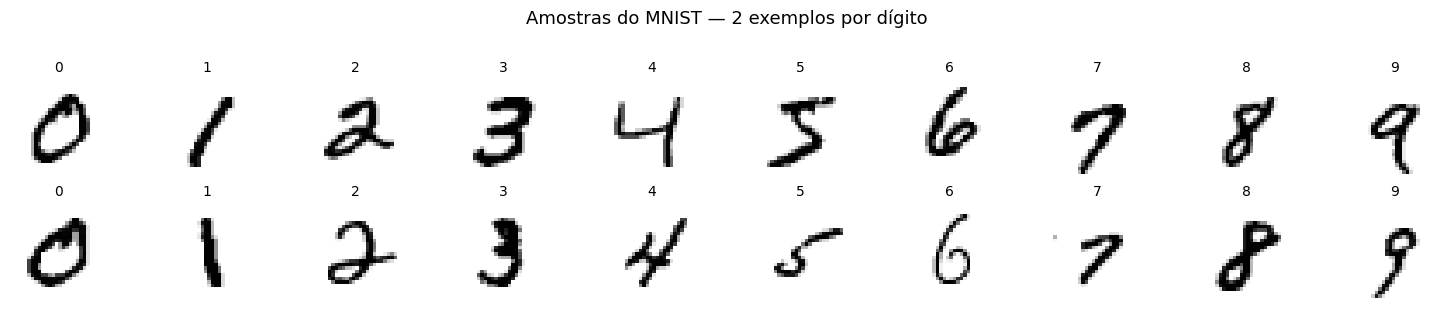

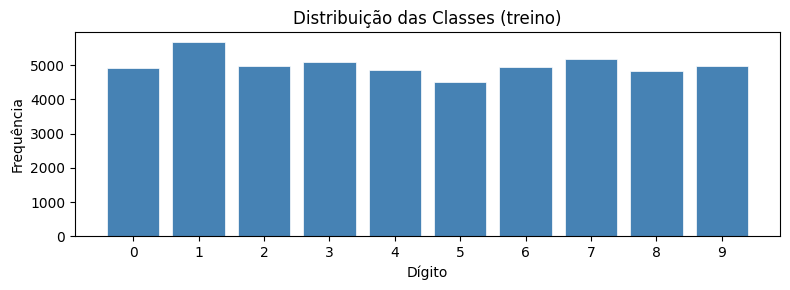

In [5]:
# ── Visualizar amostras ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
fig.suptitle('Amostras do MNIST — 2 exemplos por dígito', fontsize=13, y=1.02)

for digit in range(10):
    idxs = np.where(y_train == digit)[0][:2]
    for row, idx in enumerate(idxs):
        ax = axes[row, digit]
        ax.imshow(X_train[idx].reshape(28, 28), cmap='gray_r')
        ax.set_title(str(digit), fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.show()

# Distribuição das classes
fig, ax = plt.subplots(figsize=(8, 3))
unique, counts = np.unique(y_train, return_counts=True)
ax.bar(unique, counts, color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Dígito'); ax.set_ylabel('Frequência')
ax.set_title('Distribuição das Classes (treino)')
ax.set_xticks(range(10))
plt.tight_layout(); plt.show()

In [7]:
# ── Funções auxiliares ─────────────────────────────────────────────────────────

def build_model(hidden_layers=[256, 128], activation='relu',
                optimizer='adam', lr=0.001,
                dropout_rate=0.0, l2_lambda=0.0):
    """Constrói um MLP configurável para MNIST."""
    model = keras.Sequential(name='MLP')
    model.add(layers.Input(shape=(784,)))

    for units in hidden_layers:
        reg = regularizers.l2(l2_lambda) if l2_lambda > 0 else None
        model.add(layers.Dense(units, activation=activation, kernel_regularizer=reg))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(10, activation='softmax'))

    # Seleção do otimizador
    optimizers = {
        'sgd':      keras.optimizers.SGD(learning_rate=lr),
        'sgd_mom':  keras.optimizers.SGD(learning_rate=lr, momentum=0.9),
        'adam':     keras.optimizers.Adam(learning_rate=lr),
        'rmsprop':  keras.optimizers.RMSprop(learning_rate=lr),
        'adagrad':  keras.optimizers.Adagrad(learning_rate=lr),
        'adamw':    keras.optimizers.AdamW(learning_rate=lr),
    }
    opt = optimizers.get(optimizer, keras.optimizers.Adam(learning_rate=lr))
    model.compile(optimizer=opt,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


def train_model(model, epochs=20, batch_size=128, verbose=0):
    """Treina o modelo e retorna o histórico."""
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose
    )
    return history


def plot_histories(histories, labels, title, colors=None, figsize=(14, 5)):
    """Plota loss e acurácia (treino e validação) de múltiplos experimentos."""
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 0.9, len(histories)))

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)

    for ax, metric, ylabel in zip(
        axes,
        ['loss', 'accuracy'],
        ['Loss (Cross-Entropy)', 'Acurácia']
    ):
        for hist, label, color in zip(histories, labels, colors):
            epochs = range(1, len(hist.history[metric]) + 1)
            ax.plot(epochs, hist.history[metric],
                    color=color, linewidth=2, label=f'{label} treino')
            ax.plot(epochs, hist.history[f'val_{metric}'],
                    color=color, linewidth=2, linestyle='--',
                    alpha=0.6, label=f'{label} val')

        ax.set_xlabel('Época'); ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.legend(fontsize=8, loc='best')
        ax.grid(True, alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()


def summary_table(models_dict, X_test, y_test):
    """Gera tabela comparativa de desempenho no conjunto de teste."""
    rows = []
    for name, (model, history) in models_dict.items():
        loss, acc = model.evaluate(X_test, y_test, verbose=0)
        train_acc = history.history['accuracy'][-1]
        val_acc   = history.history['val_accuracy'][-1]
        rows.append({
            'Configuração': name,
            'Train Acc': f'{train_acc:.4f}',
            'Val Acc':   f'{val_acc:.4f}',
            'Test Acc':  f'{acc:.4f}',
            'Test Loss': f'{loss:.4f}',
        })
    return pd.DataFrame(rows).set_index('Configuração')


print('Funções auxiliares carregadas.')

Funções auxiliares carregadas.


---
## Experimento 1 — Baseline

Antes de comparar configurações, vamos estabelecer um **modelo de referência** com hiperparâmetros razoáveis. Todos os experimentos seguintes vão alterar apenas **um** parâmetro em relação a este baseline.

**Arquitetura baseline:** 784 → Dense(256, ReLU) → Dense(128, ReLU) → Dense(10, Softmax)  
**Otimizador:** Adam (lr=0.001) | **Batch:** 128 | **Épocas:** 20

In [ ]:
print('Treinando modelo baseline...')
baseline_model   = build_model()
baseline_history = train_model(baseline_model, epochs=20, verbose=1)

loss, acc = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f'\nBaseline — Test accuracy: {acc:.4f} | Test loss: {loss:.4f}')

plot_histories([baseline_history], ['Baseline'],
               title='Experimento 1 — Baseline')

# Resumo da arquitetura
baseline_model.summary()

### Perguntas — Experimento 1

1. Qual foi a acurácia final no conjunto de **teste**? Você esperava esse valor?
2. As curvas de treino e validação estão próximas? O modelo apresenta sinais de **overfitting** ou **underfitting**?
3. Em que época a melhora passou a ser marginal? O modelo precisaria de mais épocas?

---

## Experimento 2 — Otimizadores

Manteremos tudo igual ao baseline e apenas trocaremos o **algoritmo de otimização**.  
Otimizadores avaliados: `SGD`, `SGD com Momentum`, `Adam`, `RMSProp`, `Adagrad`

**O que observar:**
- Velocidade de convergência (quantas épocas para atingir 95% de acurácia?)
- Suavidade da curva de loss
- Valor final de acurácia

In [ ]:
optimizer_configs = {
    'SGD':          dict(optimizer='sgd',      lr=0.01),
    'SGD+Momentum': dict(optimizer='sgd_mom',  lr=0.01),
    'Adam':         dict(optimizer='adam',     lr=0.001),
    'RMSProp':      dict(optimizer='rmsprop',  lr=0.001),
    'Adagrad':      dict(optimizer='adagrad',  lr=0.01),
}

opt_results = {}
for name, cfg in optimizer_configs.items():
    print(f'  Treinando {name}...', end=' ')
    m = build_model(**cfg)
    h = train_model(m, epochs=20)
    opt_results[name] = (m, h)
    _, acc = m.evaluate(X_test, y_test, verbose=0)
    print(f'Test acc: {acc:.4f}')

plot_histories(
    [v[1] for v in opt_results.values()],
    list(opt_results.keys()),
    title='Experimento 2 — Comparação de Otimizadores'
)

print('\n', summary_table(opt_results, X_test, y_test).to_string())

### Perguntas — Experimento 2

1. Qual otimizador convergiu **mais rápido**? E qual obteve a **melhor acurácia final**?
2. O que o momentum fez pela curva do SGD? Por quê?
3. Adam e RMSProp têm desempenho parecido — qual é a diferença conceitual entre eles?
4. Por que o Adagrad pode ser problemático em treinamentos longos?

---

## Experimento 3 — Taxa de Aprendizado (Learning Rate)

Usando Adam como otimizador, vamos variar a **taxa de aprendizado** em uma faixa ampla.  

**O que observar:**
- LR muito alto → loss oscilante ou divergente
- LR muito baixo → convergência lenta, curvas quase planas
- LR ideal → convergência rápida e estável

In [ ]:
lr_configs = {
    'LR = 0.1   (alto)':   0.1,
    'LR = 0.01  (médio)':  0.01,
    'LR = 0.001 (ideal)':  0.001,
    'LR = 0.0001 (baixo)': 0.0001,
    'LR = 1e-5  (muito baixo)': 1e-5,
}

lr_results = {}
for name, lr in lr_configs.items():
    print(f'  Treinando {name}...', end=' ')
    m = build_model(optimizer='adam', lr=lr)
    h = train_model(m, epochs=20)
    lr_results[name] = (m, h)
    _, acc = m.evaluate(X_test, y_test, verbose=0)
    print(f'Test acc: {acc:.4f}')

plot_histories(
    [v[1] for v in lr_results.values()],
    list(lr_results.keys()),
    title='Experimento 3 — Impacto da Taxa de Aprendizado (Adam)'
)

print('\n', summary_table(lr_results, X_test, y_test).to_string())

In [ ]:
# ── BÔNUS: Learning Rate Scheduling ───────────────────────────────────────────
# Começar com LR alto e decair ao longo do tempo

def cosine_decay_schedule(initial_lr=0.01, total_epochs=20):
    def schedule(epoch, lr):
        return initial_lr * 0.5 * (1 + np.cos(np.pi * epoch / total_epochs))
    return keras.callbacks.LearningRateScheduler(schedule, verbose=0)

print('Treinando com Cosine Decay (LR 0.01 → ~0)...')
m_sched = build_model(optimizer='sgd_mom', lr=0.01)
h_sched = m_sched.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20, batch_size=128,
    callbacks=[cosine_decay_schedule()],
    verbose=0
)

m_fixed = build_model(optimizer='sgd_mom', lr=0.01)
h_fixed = train_model(m_fixed, epochs=20)

plot_histories(
    [h_fixed, h_sched],
    ['SGD+Momentum LR fixo', 'SGD+Momentum Cosine Decay'],
    title='Experimento 3 (Bônus) — LR Scheduling: Fixo vs Cosine Decay'
)

# Visualizar o schedule
lrs = [0.01 * 0.5 * (1 + np.cos(np.pi * e / 20)) for e in range(20)]
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(range(1, 21), lrs, 'o-', color='steelblue')
ax.set_xlabel('Época'); ax.set_ylabel('Learning Rate')
ax.set_title('Cosine Decay Schedule')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Perguntas — Experimento 3

1. O que aconteceu com a curva de loss para LR = 0.1? Descreva o comportamento.
2. Por que um LR muito baixo é problemático mesmo com mais épocas?
3. Como o **Cosine Decay** se saiu comparado ao LR fixo? Em que situações isso seria útil?
4. Como você escolheria um bom LR sem testar todos os valores? Pesquise sobre o "Learning Rate Finder" (Smith 2015)

---

## Experimento 4 — Arquitetura da Rede

Vamos comparar redes com diferentes **profundidade** e **largura**, mantendo o otimizador e LR fixos.

**O que observar:**
- Mais camadas aumenta capacidade, mas pode dificultar o treinamento
- Mais neurônios por camada → mais parâmetros → mais risco de overfitting
- Redes muito pequenas podem ter underfitting

In [ ]:
arch_configs = {
    'Tiny  [32]':          [32],
    'Rasa  [256]':         [256],
    'Média [256, 128]':    [256, 128],
    'Profunda [128×4]':    [128, 128, 128, 128],
    'Larga [512, 512]':    [512, 512],
    'Profunda+ [256×6]':   [256, 256, 256, 256, 256, 256],
}

arch_results = {}
for name, layers_cfg in arch_configs.items():
    m = build_model(hidden_layers=layers_cfg)
    n_params = m.count_params()
    print(f'  {name:25s} | {n_params:>8,} params | ', end='')
    h = train_model(m, epochs=20)
    arch_results[name] = (m, h)
    _, acc = m.evaluate(X_test, y_test, verbose=0)
    print(f'Test acc: {acc:.4f}')

plot_histories(
    [v[1] for v in arch_results.values()],
    list(arch_results.keys()),
    title='Experimento 4 — Impacto da Arquitetura'
)

print('\n', summary_table(arch_results, X_test, y_test).to_string())

In [ ]:
# Scatter: nº de parâmetros × acurácia de teste
param_counts, test_accs, names = [], [], []
for name, (model, _) in arch_results.items():
    _, acc = model.evaluate(X_test, y_test, verbose=0)
    param_counts.append(model.count_params())
    test_accs.append(acc)
    names.append(name)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(param_counts, test_accs, s=100, color='steelblue', zorder=3)
for i, name in enumerate(names):
    ax.annotate(name, (param_counts[i], test_accs[i]),
                textcoords='offset points', xytext=(5, 5), fontsize=8)
ax.set_xlabel('Número de Parâmetros')
ax.set_ylabel('Acurácia no Teste')
ax.set_title('Parâmetros × Acurácia — Vale a pena aumentar a rede?')
ax.grid(True, alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

### Perguntas — Experimento 4

1. A rede "Profunda+ [256×6]" se saiu melhor ou pior que a baseline? Por quê?
2. Você observou **overfitting** em alguma configuração? Como identificou?
3. Existe uma relação linear entre número de parâmetros e acurácia?

---

## Experimento 5 — Batch Size

O **batch size** determina quantos exemplos são usados para calcular cada gradiente.  
Existe um trade-off fundamental entre **eficiência computacional** e **qualidade da generalização**.

**O que observar:**
- Batch pequeno → gradiente ruidoso → mais oscilação mas potencialmente melhor generalização
- Batch grande → gradiente preciso → convergência mais suave mas pode ser pior no teste

In [ ]:
import time

batch_configs = [16, 64, 128, 512, 2048]
batch_results = {}

for bs in batch_configs:
    name = f'Batch = {bs}'
    print(f'  Treinando {name}...', end=' ')
    t0 = time.time()
    m = build_model()
    h = train_model(m, epochs=20, batch_size=bs)
    elapsed = time.time() - t0
    batch_results[name] = (m, h)
    _, acc = m.evaluate(X_test, y_test, verbose=0)
    print(f'Test acc: {acc:.4f} | Tempo: {elapsed:.1f}s')

plot_histories(
    [v[1] for v in batch_results.values()],
    list(batch_results.keys()),
    title='Experimento 5 — Impacto do Batch Size'
)

print('\n', summary_table(batch_results, X_test, y_test).to_string())

### Perguntas — Experimento 5

1. Batch = 16 gerou curvas mais **oscilantes** que batch = 2048? O que explica isso?
2. Qual batch size obteve melhor acurácia **no teste**? Isso surpreende?
3. Como o **tempo de treinamento** variou com o batch size? Existe uma relação direta?
4. O que significa dizer que batch grande tende a convergir para **mínimos agudos** (*sharp minima*)?

---

## Experimento 6 — Funções de Ativação

A função de ativação define a não-linearidade da rede. Vamos comparar as principais opções.

| Função | Faixa | Problema histórico | Observação |
|--------|-------|-------------------|------------|
| Sigmoid | (0, 1) | Vanishing gradient | Saturação nas extremidades |
| Tanh | (-1, 1) | Vanishing gradient | Melhor que sigmoid, mas ainda satura |
| ReLU | [0, ∞) | Dying ReLU | Padrão atual |
| ELU | (-1, ∞) | — | Gradientes negativos suaves |
| SELU | (-λ, ∞) | — | Auto-normalizante |

In [ ]:
activation_configs = ['sigmoid', 'tanh', 'relu', 'elu', 'selu']
act_results = {}

for act in activation_configs:
    print(f'  Treinando {act}...', end=' ')
    m = build_model(activation=act, hidden_layers=[256, 256, 128])
    h = train_model(m, epochs=20)
    act_results[act] = (m, h)
    _, acc = m.evaluate(X_test, y_test, verbose=0)
    print(f'Test acc: {acc:.4f}')

plot_histories(
    [v[1] for v in act_results.values()],
    list(act_results.keys()),
    title='Experimento 7 — Funções de Ativação'
)

print('\n', summary_table(act_results, X_test, y_test).to_string())

In [ ]:
# Visualizar as funções
x = np.linspace(-4, 4, 300)
funcs = {
    'Sigmoid': 1 / (1 + np.exp(-x)),
    'Tanh':    np.tanh(x),
    'ReLU':    np.maximum(0, x),
    'ELU':     np.where(x >= 0, x, np.exp(x) - 1),
    'SELU':    np.where(x >= 0,
                        1.0507 * x,
                        1.0507 * 1.6733 * (np.exp(x) - 1)),
}

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
for ax, (name, y_vals), color in zip(axes, funcs.items(), colors):
    ax.plot(x, y_vals, color=color, linewidth=2.5)
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='black', linewidth=0.5, alpha=0.5)
    ax.set_title(name, fontweight='bold')
    ax.set_xlim(-4, 4)
    ax.grid(True, alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Funções de Ativação', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Perguntas — Experimento 6

1. Sigmoid e Tanh sofreram com **vanishing gradient** nesta rede profunda? Evidências?
2. ReLU é mais rápido de computar que Sigmoid — por quê isso importa em redes grandes?
3. O que é o problema do **Dying ReLU** e como ELU/SELU tentam resolvê-lo?
4. Em quais arquiteturas (além de MLP) a escolha da função de ativação é ainda mais crítica?

---

---
## Conclusão — Melhor Configuração

Com base em todos os experimentos, vamos montar a melhor configuração encontrada e avaliar no conjunto de teste com uma **matriz de confusão**.

In [ ]:
# ── Treine aqui sua melhor configuração ───────────────────────────────────────
# Substitua os parâmetros com o que você aprendeu nos experimentos!

best_model = build_model(
    hidden_layers=[256, 128],   # ← altere aqui
    activation='relu',          # ← altere aqui
    optimizer='adam',           # ← altere aqui
    lr=0.001,                   # ← altere aqui
    dropout_rate=0.2,           # ← altere aqui
    l2_lambda=0.0,              # ← altere aqui
)

# Early Stopping para não precisar adivinhar o número de épocas
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1
)

best_history = best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

loss, acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f'\n🏆 Melhor modelo — Test accuracy: {acc:.4f} | Test loss: {loss:.4f}')

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = best_model.predict(X_test, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusão
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10), ax=axes[0])
axes[0].set_xlabel('Predito'); axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de Confusão')

# Normalizada (recall por classe)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10), ax=axes[1])
axes[1].set_xlabel('Predito'); axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de Confusão Normalizada (Recall)')

plt.suptitle('Análise de Erros — Melhor Modelo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nRelatório de Classificação:')
print(classification_report(y_test, y_pred, digits=4))

In [ ]:
# ── Exemplos de erro ──────────────────────────────────────────────────────────
errors = np.where(y_pred != y_test)[0]
probs  = best_model.predict(X_test, verbose=0)

# Erros com maior confiança errada
confidence = probs[errors, y_pred[errors]]
top_errors = errors[np.argsort(confidence)[::-1][:20]]

fig, axes = plt.subplots(4, 5, figsize=(12, 9))
fig.suptitle('20 Erros com Maior Confiança Equivocada', fontsize=13, fontweight='bold')

for ax, idx in zip(axes.flat, top_errors):
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray_r')
    conf = probs[idx, y_pred[idx]]
    ax.set_title(f'Real:{y_test[idx]} Pred:{y_pred[idx]}\n{conf:.2%}', fontsize=8)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#e74c3c')
        spine.set_linewidth(2)

plt.tight_layout()
plt.show()

print(f'Total de erros: {len(errors)} / {len(y_test)} ({len(errors)/len(y_test):.2%})')

### Perguntas Finais

1. Quais dígitos o modelo confunde com mais frequência? Olhando as imagens, você entende por quê?
2. Qual configuração de hiperparâmetros você escolheu como "melhor"? Justifique.
3. Se você tivesse que melhorar ainda mais o modelo, o que tentaria a seguir? (Dica: considere BatchNorm, arquiteturas convolucionais, data augmentation...)
4. Um MLP trata a imagem como um **vetor flat de 784 pixels** — que informação ele perde ao fazer isso?

---